In [213]:
import pandas as pd
import  matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [214]:
df = pd.read_csv('Salary_Data.csv')

In [215]:
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

Text(0.5, 1.0, 'Salary vs Experience')

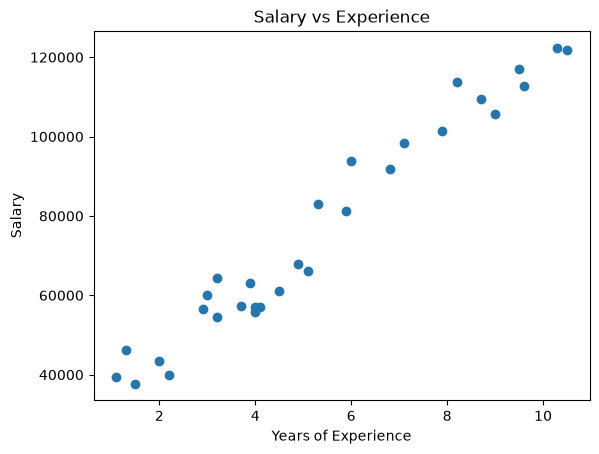

In [216]:
plt.scatter(x='YearsExperience', y='Salary', data=df)
x_label = 'Years of Experience'
y_label = 'Salary'
title = 'Salary vs Experience'
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)


In [217]:
X=df[['YearsExperience']]
y=df[['Salary']]

In [218]:
from sklearn.model_selection import train_test_split

In [219]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) 

In [220]:
lr = LinearRegression()

In [221]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[9312.58]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[26780.1]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [222]:
y_pred = lr.predict(X_test)

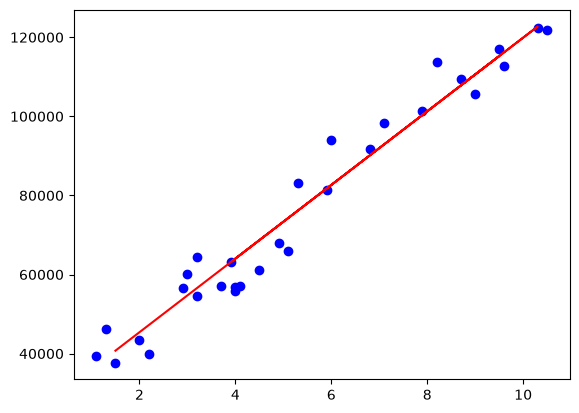

In [223]:
plt.scatter(X, y, c='b')
plt.plot(X_test, y_pred, c='r')

In [224]:
lr.score(X_test, y_test)

0.988169515729126

In [225]:
lr.score(X_train, y_train)

0.9411949620562126

In [226]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [227]:
mean_absolute_error(y_test, y_pred)

2446.1723690465055

In [228]:
mean_absolute_error(y_test, y_pred)

2446.1723690465055

In [229]:
r2_score(y_test, y_pred)

0.988169515729126

In [ ]:
# Polynomial Regression

In [249]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
poly = PolynomialFeatures(degree=6)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

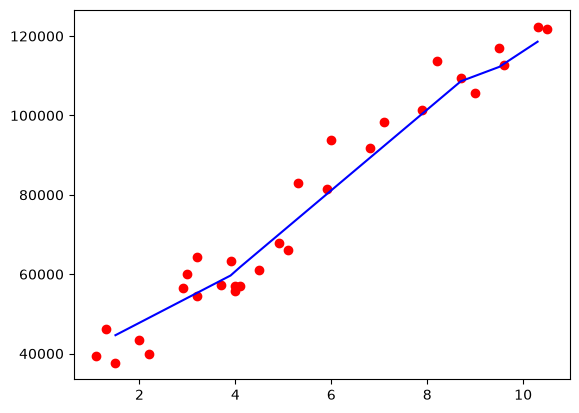

In [250]:
model = LinearRegression()
model.fit(X_train_poly, y_train)
y_pred_poly = model.predict(X_test_poly)

sort_idx = np.argsort(X_test.to_numpy().flatten())
X_test_sorted = X_test.to_numpy().flatten()[sort_idx]
y_test_sorted = y_test.to_numpy().flatten()[sort_idx]
y_pred_poly_sorted = y_pred_poly.flatten()[sort_idx]

plt.plot(X_test_sorted, y_pred_poly_sorted, c='b')
plt.scatter(X, y, c='r')



In [251]:
mean_absolute_error(y_test, y_pred_poly)

4089.0054801189